<a href="https://colab.research.google.com/github/dhiru69-tech/ML-Techniques-Lab-Project/blob/main/notebooks/day09_decision_tree_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 9: Decision Tree (Basics)
**Course:** BO CDA 205, Machine Learning Techniques
**Dataset:** German Credit (1000 customers, 21 columns)
**Syllabus link:** Supervised learning, Decision Trees

> **Goal of today:** Understand how a tree splits the data, draw and read a small tree, and see overfitting happen.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load data. bad = 1 is the positive class
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame
X = df.drop(columns=['class'])
y = df['class'].map({'good': 0, 'bad': 1}).astype(int)

# Stratified 80/20 split with a fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing fitted on train only
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

preprocess = ColumnTransformer(
    [('num', StandardScaler(), num_cols),
     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)],
    sparse_threshold=0
)
preprocess.set_output(transform="pandas")

X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)
print("Train:", X_train_p.shape, "| Test:", X_test_p.shape)


def evaluate(name, y_true, pred):
    """Return the four main metrics for the positive class (bad = 1)."""
    return {
        'model': name,
        'accuracy': round(accuracy_score(y_true, pred), 3),
        'precision': round(precision_score(y_true, pred, zero_division=0), 3),
        'recall': round(recall_score(y_true, pred, zero_division=0), 3),
        'f1': round(f1_score(y_true, pred, zero_division=0), 3),
    }

Train: (800, 61) | Test: (200, 61)


## 2. Gini Impurity by Hand

**Gini = 1 - (p_good² + p_bad²)**

| Node | Gini |
|---|---|
| all one class | 0 (pure) |
| 70 / 30 | 0.42 |
| 50 / 50 | 0.50 (most mixed) |

We compute it for our full training set, then for one example split.

In [13]:
def gini(labels):
    """Gini impurity of a set of 0/1 labels."""
    p_bad = np.mean(labels)        # fraction of 1s (bad)
    p_good = 1 - p_bad
    return 1 - (p_good**2 + p_bad**2)

print("Gini of the full training set:", round(gini(y_train), 3))

# Try one example split: customers with duration <= 18 months vs more than 18
raw_train = X_train.copy()
left = y_train[raw_train['duration'] <= 18]
right = y_train[raw_train['duration'] > 18]

weighted = (len(left) * gini(left) + len(right) * gini(right)) / len(y_train)
print("Left size:", len(left), "| Gini:", round(gini(left), 3))
print("Right size:", len(right), "| Gini:", round(gini(right), 3))
print("Weighted Gini after the split:", round(weighted, 3))
print("Gain:", round(gini(y_train) - weighted, 3))

Gini of the full training set: 0.42
Left size: 437 | Gini: 0.365
Right size: 363 | Gini: 0.467
Weighted Gini after the split: 0.411
Gain: 0.009


## 3. A Tree With No Limits

With default settings the tree keeps splitting until every leaf is pure. Watch the gap between **train** and **test** scores.

In [14]:
from sklearn.tree import DecisionTreeClassifier

# No limits: the tree can grow as deep as it wants
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train_p, y_train)

print("Depth:", tree_full.get_depth(), "| Leaves:", tree_full.get_n_leaves())
print("Train accuracy:", round(tree_full.score(X_train_p, y_train), 3))
print("Test accuracy :", round(tree_full.score(X_test_p, y_test), 3))

Depth: 18 | Leaves: 148
Train accuracy: 1.0
Test accuracy : 0.62


## 4. A Small Tree We Can Read

We limit the depth to 3. Each box in the drawing shows:

| Line in the box | Meaning |
|---|---|
| first line | the question (left branch = yes, right branch = no) |
| gini | impurity of that node |
| samples | rows that reach this node |
| value | [number of good, number of bad] |
| class | majority class, which is the prediction |

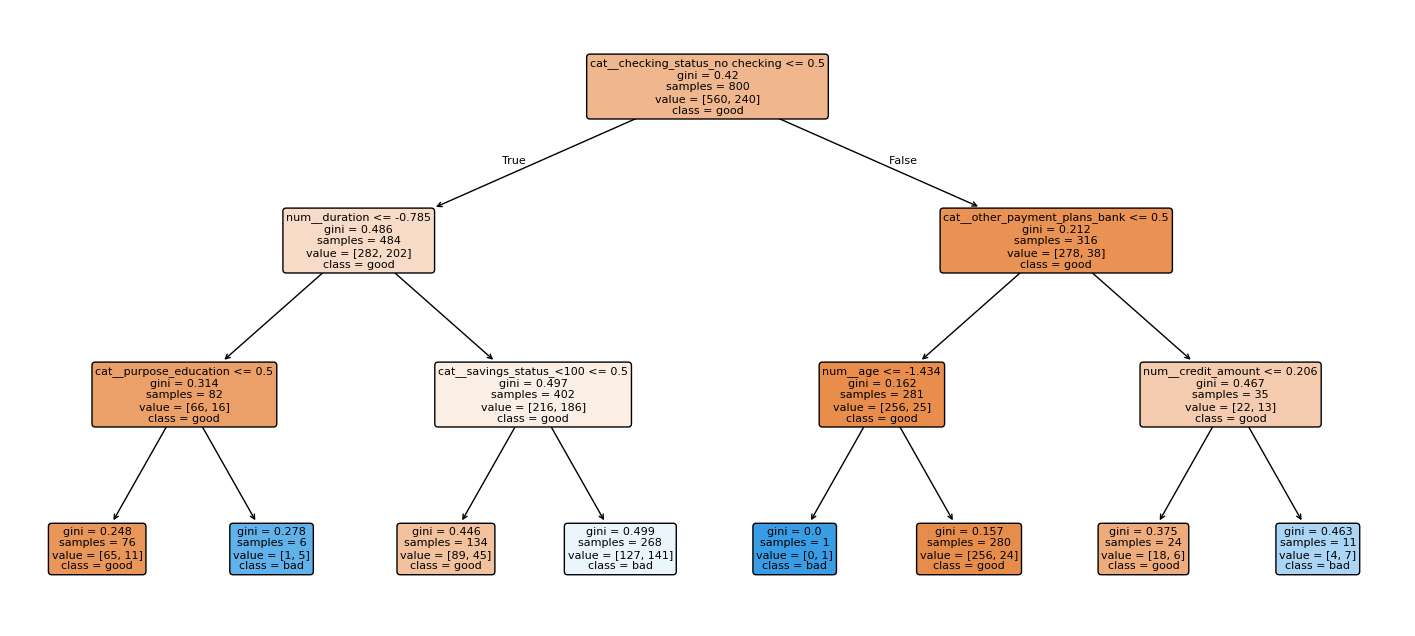

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree3.fit(X_train_p, y_train)

plt.figure(figsize=(18, 8))
plot_tree(
    tree3,
    feature_names=X_train_p.columns,
    class_names=['good', 'bad'],
    filled=True,         # color shows the majority class
    rounded=True,
    fontsize=8,
)
plt.show()

In [16]:
from sklearn.tree import export_text

print(export_text(tree3, feature_names=list(X_train_p.columns)))

|--- cat__checking_status_no checking <= 0.50
|   |--- num__duration <= -0.78
|   |   |--- cat__purpose_education <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__purpose_education >  0.50
|   |   |   |--- class: 1
|   |--- num__duration >  -0.78
|   |   |--- cat__savings_status_<100 <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__savings_status_<100 >  0.50
|   |   |   |--- class: 1
|--- cat__checking_status_no checking >  0.50
|   |--- cat__other_payment_plans_bank <= 0.50
|   |   |--- num__age <= -1.43
|   |   |   |--- class: 1
|   |   |--- num__age >  -1.43
|   |   |   |--- class: 0
|   |--- cat__other_payment_plans_bank >  0.50
|   |   |--- num__credit_amount <= 0.21
|   |   |   |--- class: 0
|   |   |--- num__credit_amount >  0.21
|   |   |   |--- class: 1



## 5. Evaluating the Trees

We use the Day 8 metrics. The positive class is **bad**.

In [17]:
# Ensure tree_full is defined and trained if it was not run previously
if 'tree_full' not in globals():
    from sklearn.tree import DecisionTreeClassifier
    tree_full = DecisionTreeClassifier(random_state=42)
    tree_full.fit(X_train_p, y_train)

results = [
    evaluate('tree (no limit)', y_test, tree_full.predict(X_test_p)),
    evaluate('tree (max_depth=3)', y_test, tree3.predict(X_test_p)),
]
pd.DataFrame(results)

,model,accuracy,precision,recall,f1
0,tree (no limit),0.62,0.371,0.383,0.377
1,tree (max_depth=3),0.67,0.461,0.583,0.515


## 6. Overfitting Curve: Accuracy vs Depth

We train trees with depth 1 to 15 and compare train and test accuracy.

- Both low: **underfitting** (tree too simple)
- Train high, test falling: **overfitting** (tree memorises)

> **Note:** here we look at the test set only to **see the overfitting pattern**. In a real project, hyperparameters are chosen using cross-validation on the training set (Day 17), so that the test set stays a fair final exam.

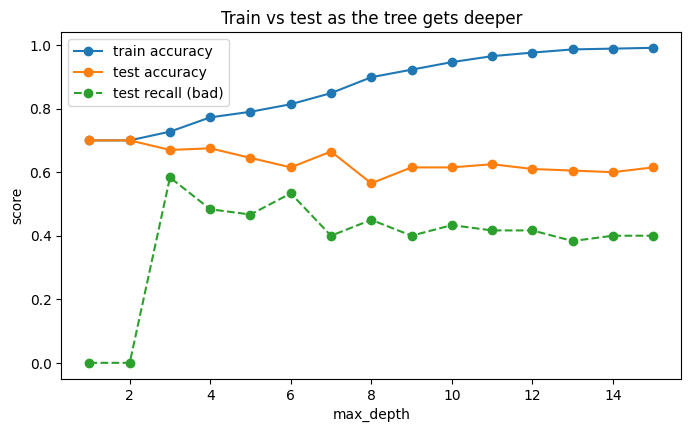

In [18]:
depths = range(1, 16)
train_scores, test_scores, test_recalls = [], [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train_p, y_train)
    train_scores.append(t.score(X_train_p, y_train))
    test_scores.append(t.score(X_test_p, y_test))
    test_recalls.append(recall_score(y_test, t.predict(X_test_p), zero_division=0))

plt.figure(figsize=(8, 4.5))
plt.plot(depths, train_scores, marker='o', label='train accuracy')
plt.plot(depths, test_scores, marker='o', label='test accuracy')
plt.plot(depths, test_recalls, marker='o', linestyle='--', label='test recall (bad)')
plt.xlabel("max_depth")
plt.ylabel("score")
plt.title("Train vs test as the tree gets deeper")
plt.legend()
plt.show()

## 7. Feature Importance

`feature_importances_` shows how much each column reduced impurity across the tree (values add up to 1).

> **Remember:** one-hot encoding turned each category into its own column (for example `cat__checking_status_<0`). The importance is therefore shown per column.

cat__checking_status_no checking    0.526
num__duration                       0.152
cat__savings_status_<100            0.101
cat__purpose_education              0.082
cat__other_payment_plans_bank       0.077
num__credit_amount                  0.035
num__age                            0.026
num__residence_since                0.000
dtype: float64


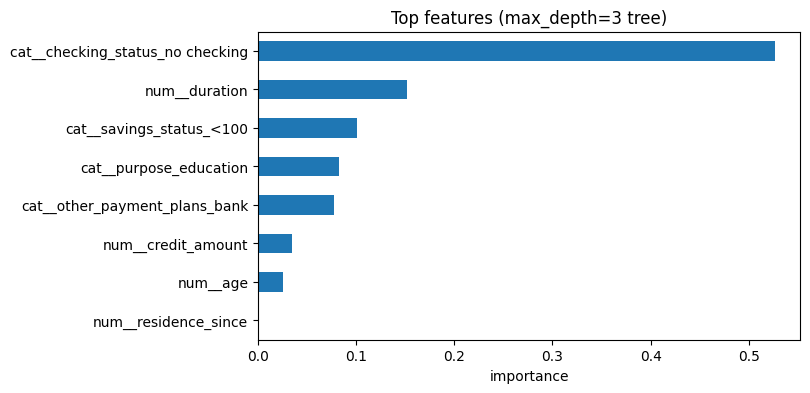

In [19]:
importance = pd.Series(tree3.feature_importances_, index=X_train_p.columns)
top = importance.sort_values(ascending=False).head(8)
print(top.round(3))

top.sort_values().plot(kind='barh', figsize=(7, 4))
plt.title("Top features (max_depth=3 tree)")
plt.xlabel("importance")
plt.show()

## 8. Handling the 70/30 Imbalance with `class_weight`

`class_weight='balanced'` tells the tree to treat mistakes on the rarer class (bad) as more serious. This usually **raises recall** for bad customers, at the cost of precision.

> Recall that a missed bad customer is the costly mistake (Day 8).

In [20]:
tree_bal = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree_bal.fit(X_train_p, y_train)

tree4 = DecisionTreeClassifier(max_depth=4, random_state=42)
tree4.fit(X_train_p, y_train)

results = [
    evaluate('tree depth 4', y_test, tree4.predict(X_test_p)),
    evaluate('tree depth 4, balanced', y_test, tree_bal.predict(X_test_p)),
]
pd.DataFrame(results)

,model,accuracy,precision,recall,f1
0,tree depth 4,0.675,0.460,0.483,0.472
1,"tree depth 4, balanced",0.625,0.419,0.650,0.510
